Loaded the Dataset and read it

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('/content/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Removed the duplicates

In [ ]:
duplicates=df.duplicated().sum()
print(f"No of Duplicates Rows:{duplicates}")
df.drop_duplicates(inplace=True)
df.head()

No of Duplicates Rows:0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Analysed the types of data in the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Find the mean mode minimum 25th 75th values

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Print the values

In [ ]:
print("Median Quantity:", df['Quantity'].median())
print("Median Price:", df['Price per Unit'].median())
print("Median Total Amount:", df['Total Amount'].median())
print("Mode Quantity:", df['Quantity'].mode())
print("Mode Price:", df['Price per Unit'].mode())
print("Mode Total Amount:", df['Total Amount'].mode())

Median Quantity: 3.0
Median Price: 50.0
Median Total Amount: 135.0
Mode Quantity: 0    4
Name: Quantity, dtype: int64
Mode Price: 0    50
Name: Price per Unit, dtype: int64
Mode Total Amount: 0    50
Name: Total Amount, dtype: int64


Types of attributes in each coloumns

In [ ]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


Standardisation and Normalisation

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Total Amount_minmax'] = scaler.fit_transform(df[['Total Amount']])
df['Quantity_minmax'] = scaler.fit_transform(df[['Quantity']])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total Amount_minmax,Quantity_minmax
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,0.666667
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,0.333333
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,0.000000
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,0.000000
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,0.333333


Finding the Z-Score

In [ ]:
df['Total Amount_zscore'] = (df['Total Amount'] - df['Total Amount'].mean()) / df['Total Amount'].std()
df.head()
df['Quantity_zscore'] = (df['Quantity'] - df['Quantity'].mean()) / df['Quantity'].std()
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Total Amount_minmax,Quantity_minmax,Total Amount_zscore,Quantity_zscore
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,0.666667,-0.546431,0.429050
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,0.333333,0.971433,-0.453769
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,0.000000,-0.760718,-1.336589
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,0.000000,0.078572,-1.336589
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,0.333333,-0.635717,-0.453769


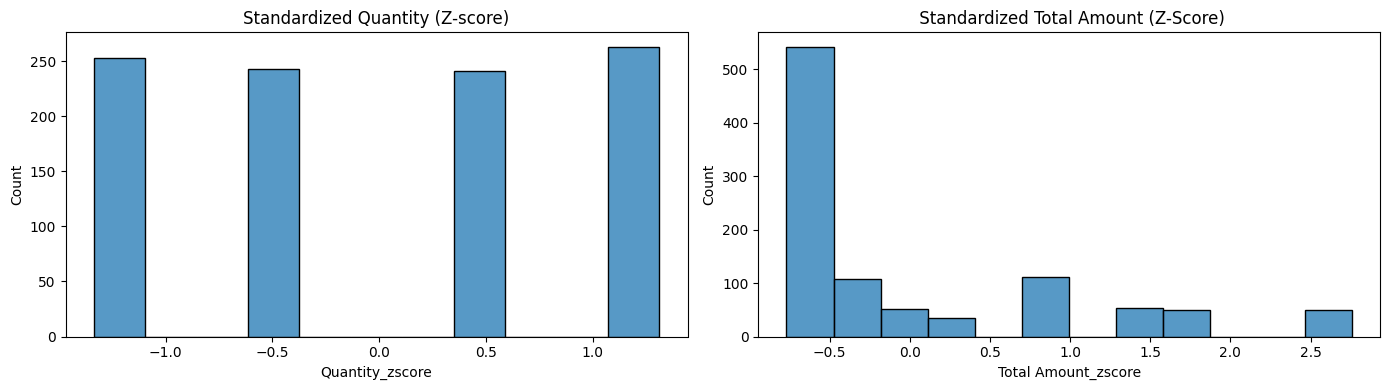

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['Quantity_zscore'], ax=axes[0])
axes[0].set_title("Standardized Quantity (Z-score)")
sns.histplot(df['Total Amount_zscore'], ax=axes[1])
axes[1].set_title(" Standardized Total Amount (Z-Score)")
plt.tight_layout()
plt.show()

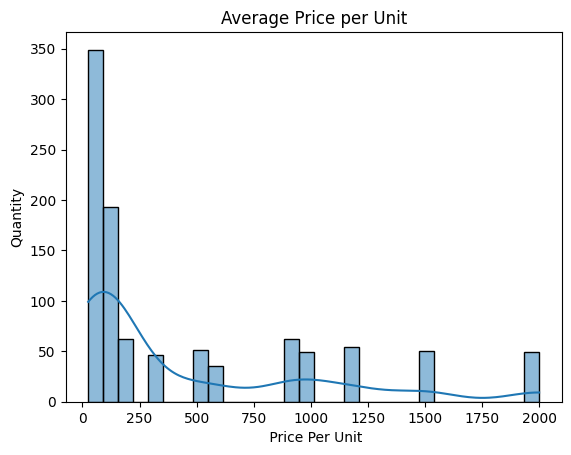

In [ ]:
sns.histplot(df['Total Amount'], bins=30, kde=True)
plt.title("Average Price per Unit")
plt.xlabel(" Price Per Unit")
plt.ylabel("Quantity")
plt.show()

In [ ]:
average_price = df['Price per Unit'].mean()
print(f"Average Price per Unit: {average_price:.2f}")

Average Price per Unit: 179.89


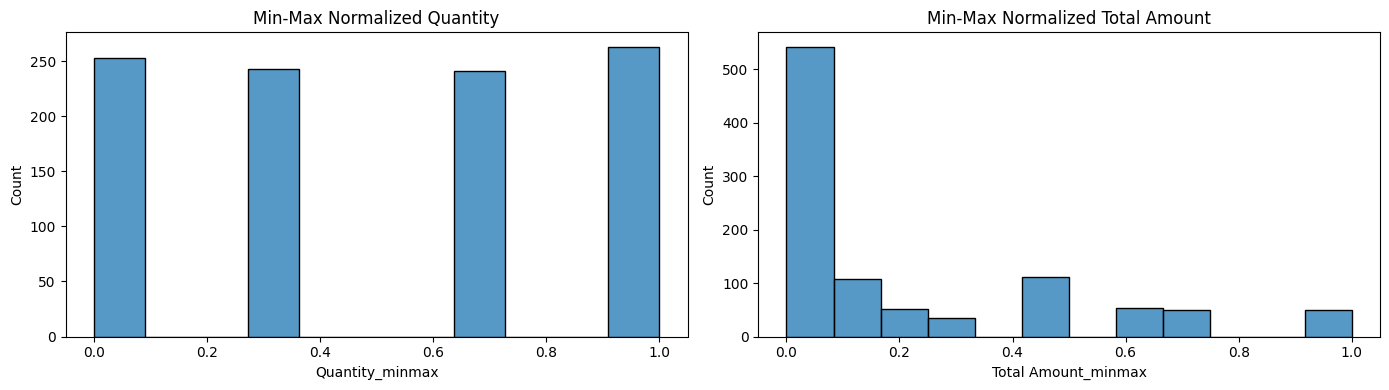

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df['Quantity_minmax'], ax=axes[0])
axes[0].set_title("Min-Max Normalized Quantity")
sns.histplot(df['Total Amount_minmax'], ax=axes[1])
axes[1].set_title("Min-Max Normalized Total Amount")
plt.tight_layout()
plt.show()

Plotting and findout relations between the Attributes Gender, Age, Product Category, Quantity, Price per Unit, Date

array([<Axes: ylabel='count'>], dtype=object)

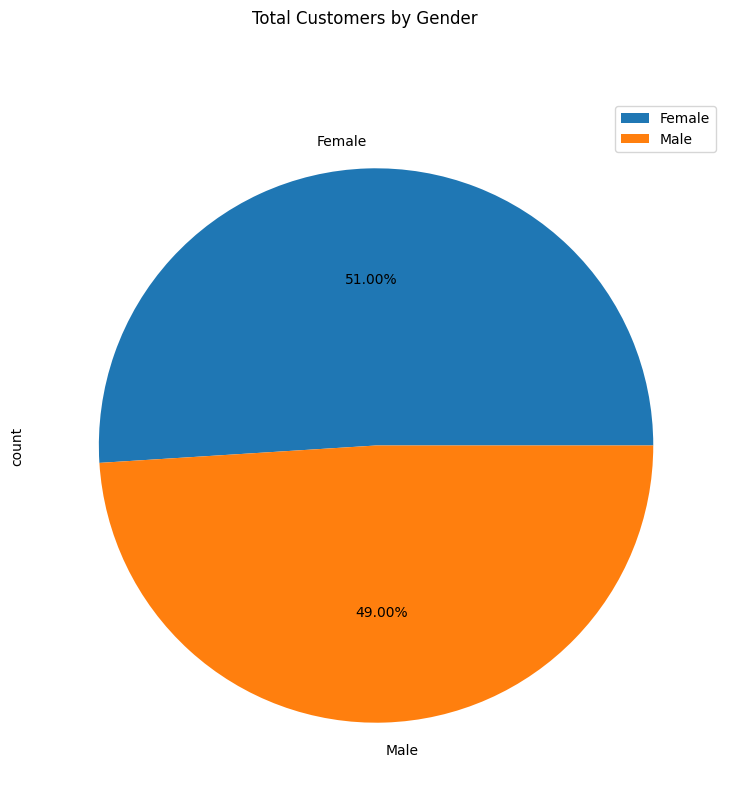

In [ ]:
df.groupby('Gender')['Transaction ID'].agg(['count']).sort_values(by='count',ascending=False).plot(kind='pie',autopct='%1.2f%%',subplots=True,title='Total Customers by Gender',figsize=(9,9))

In [ ]:
retailstore= pd.read_csv('/content/retail_sales_dataset.csv')
retailstore.head()
retailstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
Total_Amount_by_Gender=retailstore.groupby('Gender')['Total Amount'].sum().reset_index()
print(Total_Amount_by_Gender.head())

   Gender  Total Amount
0  Female        232840
1    Male        223160


In [ ]:
import plotly.express as px
fig = px.bar(
    Total_Amount_by_Gender,
    x='Gender',
    y='Total Amount',
    color='Gender',
    color_discrete_map={'Female': 'red', 'Male': 'blue'},
    title='Total Sales by Gender'
)
fig.show()

In [ ]:
Total_Amount_by_Product_Category = retailstore.groupby('Product Category')['Total Amount'].sum().reset_index()
print(Total_Amount_by_Product_Category.head())

  Product Category  Total Amount
0           Beauty        143515
1         Clothing        155580
2      Electronics        156905


In [ ]:
import plotly.express as px
fig = px.bar(
    Total_Amount_by_Product_Category,
    x='Product Category',
    y='Total Amount',
    title='Total Sales by Product Category',
    color='Product Category',
    color_discrete_map={'Clothing': 'red', 'Shoes': 'blue', 'Electronics': 'green'}
)
fig.show()

In [ ]:
Total_Amount_by_Gender_and_Product_Category = retailstore.groupby(['Gender', 'Product Category'])['Total Amount'].sum().reset_index()
print(Total_Amount_by_Gender_and_Product_Category.head(6))

   Gender Product Category  Total Amount
0  Female           Beauty         74830
1  Female         Clothing         81275
2  Female      Electronics         76735
3    Male           Beauty         68685
4    Male         Clothing         74305
5    Male      Electronics         80170


In [ ]:
import plotly.express as px
fig = px.bar(
    Total_Amount_by_Gender_and_Product_Category,
    x='Product Category',
    y='Total Amount',
    color='Gender',
    title='Total Sales by Gender and Product Category',
    barmode='group'
)
fig.show()

In [ ]:
Total_Amount_by_Age = retailstore.groupby('Age')['Total Amount'].sum().reset_index()
print(Total_Amount_by_Age.head(100))

    Age  Total Amount
0    18         11215
1    19         14870
2    20          8645
3    21         12585
4    22         13700
5    23          8220
6    24          5415
7    25          9900
8    26         13980
9    27          9385
10   28          8670
11   29          6570
12   30          9790
13   31         10220
14   32          5550
15   33          6240
16   34         16785
17   35         11290
18   36          9105
19   37         11650
20   38         11100
21   39          4595
22   40          9415
23   41          5650
24   42          8500
25   43         17970
26   44          7560
27   45          6325
28   46         13090
29   47         12505
30   48          7240
31   49          5110
32   50          9845
33   51         16065
34   52          7040
35   53          9510
36   54         10505
37   55          9780
38   56          9440
39   57          9290
40   58          7395
41   59          9470
42   60         11590
43   61          6730
44   62   

In [ ]:
import plotly.express as px
fig = px.bar(
    Total_Amount_by_Age,
    x='Age',
    y='Total Amount',
    color='Age',
    title='Total Sales by Age'
)
fig.show()

In [ ]:
Total_Amount_by_Age_and_Product_Category = retailstore.groupby(['Age', 'Product Category'])['Total Amount'].sum().reset_index()
print(Total_Amount_by_Age_and_Product_Category.head(100))

    Age Product Category  Total Amount
0    18           Beauty          4960
1    18         Clothing          4085
2    18      Electronics          2170
3    19           Beauty          4365
4    19         Clothing          2730
..  ...              ...           ...
95   49      Electronics           875
96   50           Beauty          2200
97   50         Clothing           950
98   50      Electronics          6695
99   51           Beauty          4575

[100 rows x 3 columns]


In [ ]:
import plotly.express as px
fig = px.bar(
    Total_Amount_by_Age_and_Product_Category,
    x='Age',
    y='Total Amount',
    color='Product Category',
    title='Total Sales by Age and Product Category',
)
fig.show()

/tmp/ipython-input-3624483805.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



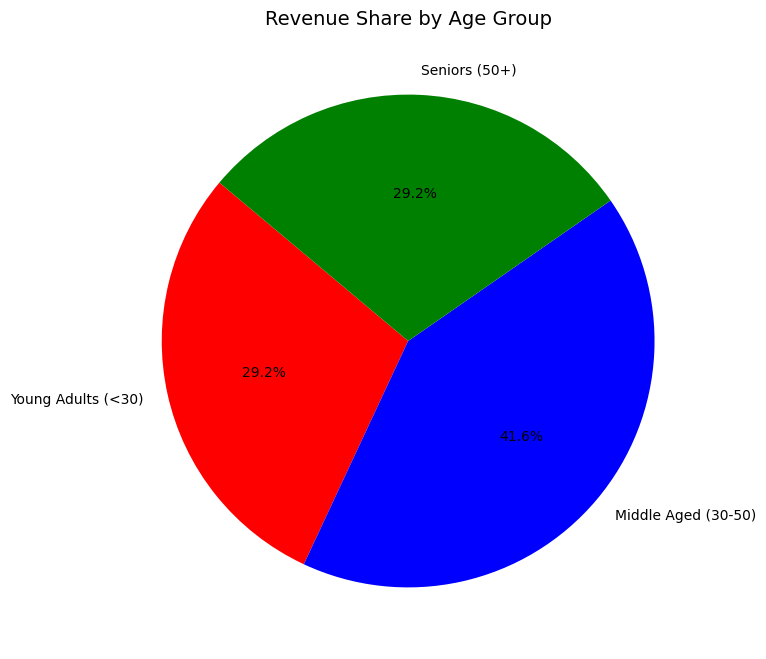

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/retail_sales_dataset.csv')
df.drop_duplicates(inplace=True)

bins = [0, 30, 50, 100]
labels = ['Young Adults (<30)', 'Middle Aged (30-50)', 'Seniors (50+)']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_sales = df.groupby('Age Group')['Total Amount'].sum()
plt.figure(figsize=(8, 8))
plt.pie(age_sales, labels=age_sales.index, autopct='%1.1f%%',
        colors=['Red', 'Blue', 'Green'], startangle=140)
plt.title('Revenue Share by Age Group', fontsize=14)
plt.show()

In [ ]:
fig=px.line(Total_Amount_by_Age_and_Product_Category,x='Age',y='Total Amount',color='Product Category',title='Scatterplot on Age and Product Category')
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

if 'Age Group' not in df.columns:
    bins = [0, 30, 50, 100]
    labels = ['Young Adults (<30)', 'Middle Aged (30-50)', 'Seniors (50+)']
    df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

contingency_table_age_product = pd.crosstab(df['Age Group'], df['Product Category'])
contingency_df_age_product = contingency_table_age_product.stack().reset_index(name='Count')

fig = px.bar(
    contingency_df_age_product,
    x='Age Group',
    y='Count',
    color='Product Category',
    barmode='group',
    title='Product Category Distribution by Age Group'
)
fig.show()

In [ ]:
import plotly.graph_objects as go
fig=go.Figure(data=go.Heatmap(
    x=Total_Amount_by_Age_and_Product_Category['Age'],
    y=Total_Amount_by_Age_and_Product_Category['Product Category'],
    z=Total_Amount_by_Age_and_Product_Category['Total Amount'],
    colorscale='Viridis'
))
fig.update_layout(title='Total Sales by Age and Product Category. x=Age,y=Product Category,z=Total Amount')
fig.show()

In [ ]:
retailstore['Date'] = pd.to_datetime(retailstore['Date'])
Monthly_Sales = retailstore.groupby([retailstore['Date'].dt.to_period('M')])['Total Amount'].sum().reset_index()
Monthly_Sales['Date'] = Monthly_Sales['Date'].dt.to_timestamp(freq='M')
Monthly_Sales = Monthly_Sales.iloc[:-1]
print(Monthly_Sales.head(100))

         Date  Total Amount
0  2023-01-31         35450
1  2023-02-28         44060
2  2023-03-31         28990
3  2023-04-30         33870
4  2023-05-31         53150
5  2023-06-30         36715
6  2023-07-31         35465
7  2023-08-31         36960
8  2023-09-30         23620
9  2023-10-31         46580
10 2023-11-30         34920
11 2023-12-31         44690


In [ ]:
import plotly.express as px
fig = px.line(
    Monthly_Sales,
    x= 'Date',
    y='Total Amount',
    title='Monthly Sales Trend'
)
fig.show()

In [ ]:
retailstore['Date'] = pd.to_datetime(retailstore['Date'])
Monthly_Sales_by_Category = retailstore.groupby([retailstore['Date'].dt.to_period('M'),'Gender','Age','Quantity','Product Category'])['Total Amount'].sum().reset_index()
Monthly_Sales_by_Category['Date'] = Monthly_Sales_by_Category['Date'].apply(lambda x: x.to_timestamp(freq='M'))
Monthly_Sales_by_Category = Monthly_Sales_by_Category[Monthly_Sales_by_Category['Date']<'2024-01-01']
print(Monthly_Sales_by_Category.head(100))

         Date  Gender  Age  Quantity Product Category  Total Amount
0  2023-01-31  Female   18         3           Beauty            90
1  2023-01-31  Female   19         1           Beauty            25
2  2023-01-31  Female   19         4         Clothing          1200
3  2023-01-31  Female   19         4      Electronics           200
4  2023-01-31  Female   20         1      Electronics            30
..        ...     ...  ...       ...              ...           ...
95 2023-02-28  Female   43         2      Electronics            50
96 2023-02-28  Female   43         3         Clothing          1500
97 2023-02-28  Female   44         2      Electronics           600
98 2023-02-28  Female   45         4           Beauty           100
99 2023-02-28  Female   46         1           Beauty            25

[100 rows x 6 columns]


In [ ]:
import plotly.express as px
fig = px.bar(
    Monthly_Sales_by_Category,
    x='Product Category',
    y='Total Amount',
    animation_frame='Date',
    barmode='group',
    color='Product Category',
    title='Monthly Sales by Category (Animated)',
    height=700,
    range_y=[50, 150000],
    template='plotly_dark',
    hover_data=['Product Category']
)


fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    retailstore,
    x='Quantity',
    y='Total Amount',
    title='Quantity vs. Total Amount',
    hover_data=['Product Category', 'Gender', 'Age']

)
fig.show()

In [ ]:
Total_Amount_by_Date = retailstore.groupby(['Date'])['Total Amount'].sum().reset_index()
print(Total_Amount_by_Date.head(100))

         Date  Total Amount
0  2023-01-01          3600
1  2023-01-02          1765
2  2023-01-03           600
3  2023-01-04          1240
4  2023-01-05          1100
..        ...           ...
95 2023-04-13           360
96 2023-04-15           700
97 2023-04-16           300
98 2023-04-17            25
99 2023-04-18           500

[100 rows x 2 columns]


In [ ]:
fig = px.bar(
    Total_Amount_by_Date,
    x='Date',
    y='Total Amount',
    title='Total Sales by Date'
)
fig.show()

In [ ]:
fig = px.histogram(retailstore, x='Age', histnorm='density', title='Density Plot of Profit Distribution')
fig.show()

In [ ]:
fig = px.histogram(retailstore, x='Gender', histnorm='density', title='Density Plot of Profit Distribution')
fig.show()

Finding Co relations

In [ ]:
cr=df[['Age','Quantity','Total Amount','Price per Unit']]
print(cr.head())

   Age  Quantity  Total Amount  Price per Unit
0   34         3           150              50
1   26         2          1000             500
2   50         1            30              30
3   37         1           500             500
4   30         2           100              50


In [ ]:
correlation=cr.corr()
print(correlation)

                     Age  Quantity  Total Amount  Price per Unit
Age             1.000000 -0.023737     -0.060568       -0.038423
Quantity       -0.023737  1.000000      0.373707        0.017501
Total Amount   -0.060568  0.373707      1.000000        0.851925
Price per Unit -0.038423  0.017501      0.851925        1.000000


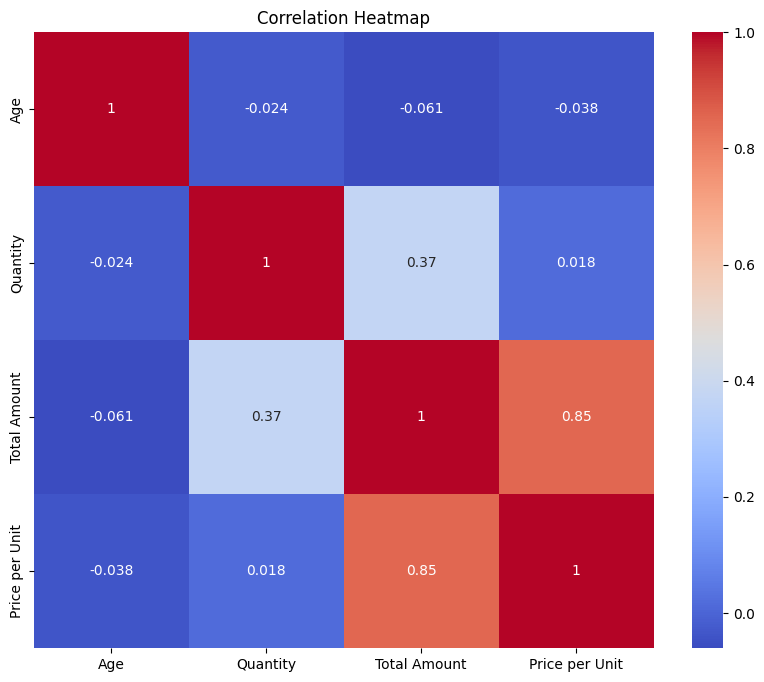

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
import plotly.express as px

fig = px.histogram(df, x='Price per Unit', title='Distribution of Price per Unit', nbins=30)
fig.show()

In [ ]:
import plotly.express as px
avg_sales_by_product = df.groupby('Product Category')['Total Amount'].mean().reset_index()

fig = px.bar(
    avg_sales_by_product,
    x='Product Category',
    y='Total Amount',
    title='Average Total Amount by Product Category',
    color='Product Category'
)
fig.show()

In [ ]:
import plotly.express as px

avg_sales_by_gender = df.groupby('Gender')['Total Amount'].mean().reset_index()

fig = px.bar(
    avg_sales_by_gender,
    x='Gender',
    y='Total Amount',
    title='Average Total Amount by Gender',
    color='Gender'
)
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

contingency_table_gender_product = pd.crosstab(df['Gender'], df['Product Category'])
contingency_df_gender_product = contingency_table_gender_product.stack().reset_index(name='Count')

fig = px.bar(
    contingency_df_gender_product,
    x='Gender',
    y='Count',
    color='Product Category',
    barmode='group',
    title='Product Category Distribution by Gender'
)
fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

contingency_table_quantity_product = pd.crosstab(df['Quantity'], df['Product Category'])
contingency_df_quantity_product = contingency_table_quantity_product.stack().reset_index(name='Count')

fig = px.bar(
    contingency_df_quantity_product,
    x='Quantity',
    y='Count',
    color='Product Category',
    barmode='group',
    title='Product Category Distribution by Quantity Purchased'
)
fig.show()

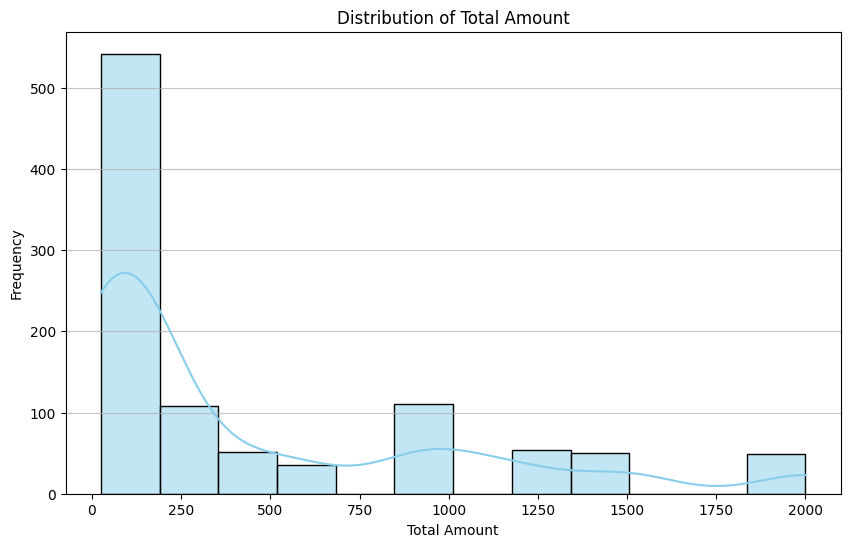

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Amount'], kde=True, color='skyblue')
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

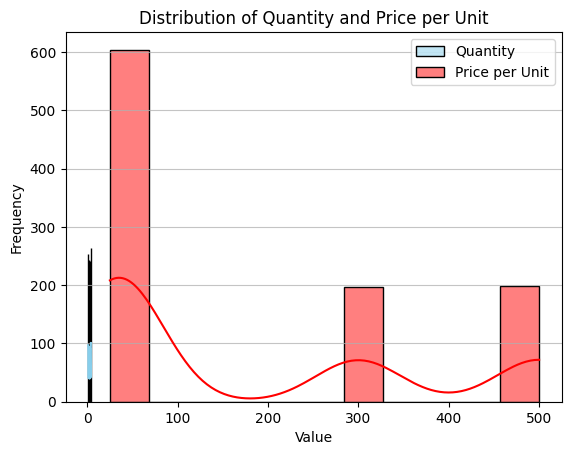

In [ ]:
sns.histplot(df['Quantity'],color='skyblue', label='Quantity', kde=True, alpha=0.5)
sns.histplot(df['Price per Unit'], color='red', label='Price per Unit', kde=True, alpha=0.5)

plt.title('Distribution of Quantity and Price per Unit')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Performing Co relation tests on the attributes

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Total Amount_minmax'] = scaler.fit_transform(df[['Total Amount']])
df['Quantity_minmax'] = scaler.fit_transform(df[['Quantity']])


df['Total Amount_zscore'] = (df['Total Amount'] - df['Total Amount'].mean()) / df['Total Amount'].std()
df['Quantity_zscore'] = (df['Quantity'] - df['Quantity'].mean()) / df['Quantity'].std()

print("--- Original Data Statistics ---")
print(df[['Total Amount', 'Quantity']].describe())

print("\n--- Standardized (Z-score) Data Statistics ---")
print(df[['Total Amount_zscore', 'Quantity_zscore']].describe())

print("\n--- Min-Max Normalized Data Statistics ---")
print(df[['Total Amount_minmax', 'Quantity_minmax']].describe())

--- Original Data Statistics ---
       Total Amount     Quantity
count   1000.000000  1000.000000
mean     456.000000     2.514000
std      559.997632     1.132734
min       25.000000     1.000000
25%       60.000000     1.000000
50%      135.000000     3.000000
75%      900.000000     4.000000
max     2000.000000     4.000000

--- Standardized (Z-score) Data Statistics ---
       Total Amount_zscore  Quantity_zscore
count          1000.000000     1.000000e+03
mean              0.000000     2.176037e-16
std               1.000000     1.000000e+00
min              -0.769646    -1.336589e+00
25%              -0.707146    -1.336589e+00
50%              -0.573217     4.290503e-01
75%               0.792860     1.311870e+00
max               2.757155     1.311870e+00

--- Min-Max Normalized Data Statistics ---
       Total Amount_minmax  Quantity_minmax
count          1000.000000      1000.000000
mean              0.218228         0.504667
std               0.283543         0.377578
min   

In [ ]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
correlation_df = df[numerical_cols]

pearson_corr = correlation_df.corr(method='pearson')
print("Pearson Correlation Matrix:")
print(pearson_corr)

Pearson Correlation Matrix:
                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


In [ ]:
spearman_corr = correlation_df.corr(method='spearman')
print("Spearman Correlation Matrix:")
print(spearman_corr)

Spearman Correlation Matrix:
                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023472       -0.037966     -0.037864
Quantity       -0.023472  1.000000        0.024014      0.474103
Price per Unit -0.037966  0.024014        1.000000      0.857439
Total Amount   -0.037864  0.474103        0.857439      1.000000


Pearson Corelation

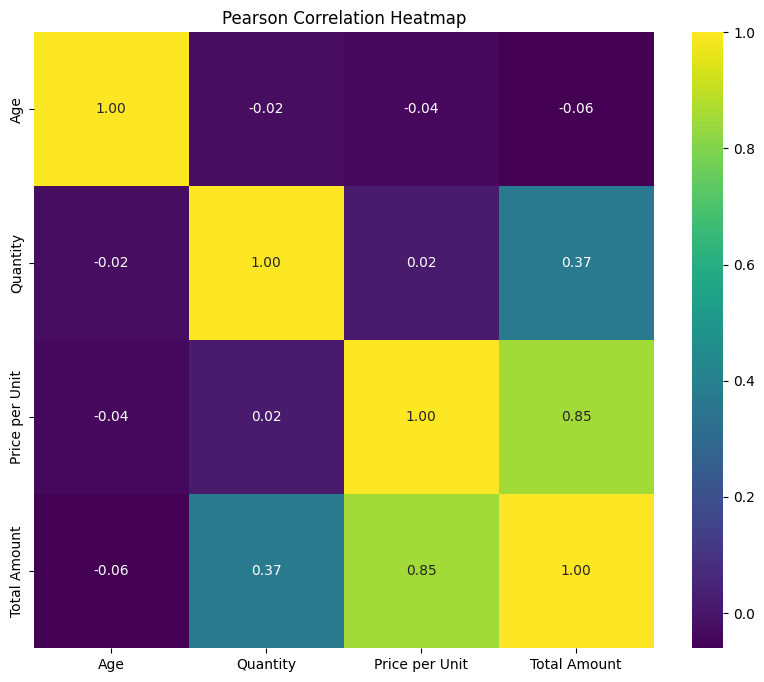

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
correlation_df = df[numerical_cols]
pearson_corr = correlation_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='viridis', fmt=".2f")
plt.title('Pearson Correlation Heatmap')
plt.show()

Spearman Corelation

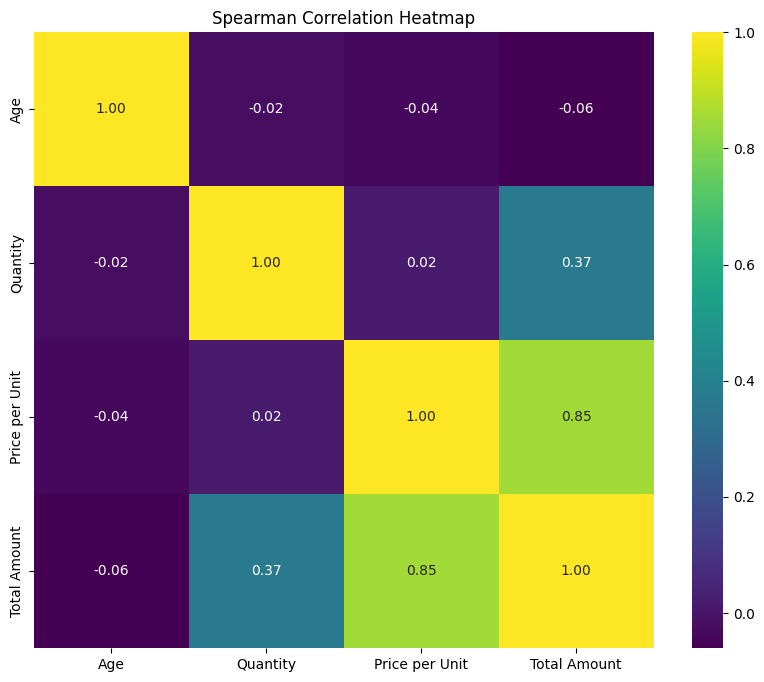

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
correlation_df = df[numerical_cols]
spearman_corr = correlation_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='viridis', fmt=".2f")
plt.title('Spearman Correlation Heatmap')
plt.show()

Finding and justifying Hypothesis

t-test

In [ ]:
from scipy.stats import ttest_ind
beauty_quantity = df[df['Product Category'] == 'Beauty']['Quantity']
clothing_quantity = df[df['Product Category'] == 'Clothing']['Quantity']
electronics_quantity = df[df['Product Category'] == 'Electronics']['Quantity']
t_stat_bc, p_value_bc = ttest_ind(beauty_quantity, clothing_quantity)
print(f"1. T-test (Quantity for Beauty vs. Clothing):\n   t-statistic: {t_stat_bc:.2f}\n   p-value: {p_value_bc:.3f}")
t_stat_ec, p_value_ec = ttest_ind(electronics_quantity, clothing_quantity)
print(f"2. T-test (Quantity for Electronics vs. Clothing):\n   t-statistic: {t_stat_ec:.2f}\n   p-value: {p_value_ec:.3f}")
t_stat_be, p_value_be = ttest_ind(beauty_quantity, electronics_quantity)
print(f"3. T-test (Quantity for Beauty vs. Electronics):\n   t-statistic: {t_stat_be:.2f}\n   p-value: {p_value_be:.3f}")

beauty_total_amount = df[df['Product Category'] == 'Beauty']['Total Amount']
clothing_total_amount = df[df['Product Category'] == 'Clothing']['Total Amount']
electronics_total_amount = df[df['Product Category'] == 'Electronics']['Total Amount']
t_stat_bc, p_value_bc = ttest_ind(beauty_total_amount, clothing_total_amount)
print(f"4. T-test (Total Amount for Beauty vs. Clothing):\n   t-statistic: {t_stat_bc:.2f}\n   p-value: {p_value_bc:.3f}")
t_stat_ec, p_value_ec = ttest_ind(electronics_total_amount, clothing_total_amount)
print(f"5. T-test (Total Amount for Electronics vs. Clothing):\n   t-statistic: {t_stat_ec:.2f}\n   p-value: {p_value_ec:.3f}")
t_stat_be, p_value_be = ttest_ind(beauty_total_amount, electronics_total_amount)
print(f"6. T-test (Total Amount for Beauty vs. Electronics):\n   t-statistic: {t_stat_be:.2f}\n   p-value: {p_value_be:.3f}")

beauty_age = df[df['Product Category'] == 'Beauty']['Age']
clothing_age = df[df['Product Category'] == 'Clothing']['Age']
electronics_age = df[df['Product Category'] == 'Electronics']['Age']
t_stat_bc, p_value_bc = ttest_ind(beauty_age, clothing_age)
print(f"7. T-test (Age for Beauty vs. Clothing):\n   t-statistic: {t_stat_bc:.2f}\n   p-value: {p_value_bc:.3f}")
t_stat_ec, p_value_ec = ttest_ind(electronics_age, clothing_age)
print(f"8. T-test (Age for Electronics vs. Clothing):\n   t-statistic: {t_stat_ec:.2f}\n   p-value: {p_value_ec:.3f}")
t_stat_be, p_value_be = ttest_ind(beauty_age, electronics_age)
print(f"9. T-test (Age for Beauty vs. Electronics):\n   t-statistic: {t_stat_be:.2f}\n   p-value: {p_value_be:.3f}")



1. T-test (Quantity for Beauty vs. Clothing):
   t-statistic: -0.41
   p-value: 0.685
2. T-test (Quantity for Electronics vs. Clothing):
   t-statistic: -0.74
   p-value: 0.459
3. T-test (Quantity for Beauty vs. Electronics):
   t-statistic: 0.33
   p-value: 0.744
4. T-test (Total Amount for Beauty vs. Clothing):
   t-statistic: 0.56
   p-value: 0.578
5. T-test (Total Amount for Electronics vs. Clothing):
   t-statistic: 0.37
   p-value: 0.715
6. T-test (Total Amount for Beauty vs. Electronics):
   t-statistic: 0.20
   p-value: 0.845
7. T-test (Age for Beauty vs. Clothing):
   t-statistic: -1.48
   p-value: 0.141
8. T-test (Age for Electronics vs. Clothing):
   t-statistic: -0.21
   p-value: 0.837
9. T-test (Age for Beauty vs. Electronics):
   t-statistic: -1.26
   p-value: 0.208


ANOVA Test

In [ ]:
from scipy.stats import f_oneway

product_categories = df['Product Category'].unique()
total_amount_by_category = [df['Total Amount'][df['Product Category'] == category] for category in product_categories]

f_statistic, p_value = f_oneway(*total_amount_by_category)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

F-statistic: 0.16
P-value: 0.853


Chi-Square test

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Gender'], df['Product Category'])
chi2_statistic, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2_statistic)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected_frequencies)

Chi-square Statistic: 1.673837085800602
P-value: 0.43304287262068974
Degrees of Freedom: 2
Expected Frequencies:
 [[156.57 179.01 174.42]
 [150.43 171.99 167.58]]


Standardised t-test

In [ ]:
from scipy.stats import f_oneway

product_categories = df['Product Category'].unique()
total_amount_zscore_by_category = [df['Total Amount_zscore'][df['Product Category'] == category] for category in product_categories]

f_statistic_zscore, p_value_zscore = f_oneway(*total_amount_zscore_by_category)

print(f"F-statistic (Standardized Data): {f_statistic_zscore:.2f}")
print(f"P-value (Standardized Data): {p_value_zscore:.3f}")

F-statistic (Standardized Data): 0.16
P-value (Standardized Data): 0.853


In [ ]:
from scipy.stats import ttest_ind

beauty_total_amount_zscore = df[df['Product Category'] == 'Beauty']['Total Amount_zscore']
clothing_total_amount_zscore = df[df['Product Category'] == 'Clothing']['Total Amount_zscore']
electronics_total_amount_zscore = df[df['Product Category'] == 'Electronics']['Total Amount_zscore']

t_statistic_zscore, p_value_zscore_ttest = ttest_ind(beauty_total_amount_zscore, clothing_total_amount_zscore)
t_statistic_zscore, p_value_zscore_ttest = ttest_ind(electronics_total_amount_zscore, clothing_total_amount_zscore)
t_statistic_zscore, p_value_zscore_ttest = ttest_ind(beauty_total_amount_zscore, electronics_total_amount_zscore)

print(f"T-test (Standardized Total Amount for Beauty vs. Clothing):\n   t-statistic: {t_statistic_zscore:.2f}\n   p-value: {p_value_zscore_ttest:.3f}")
print(f"T-test (Standardized Total Amount for Electronics vs. Clothing):\n   t-statistic: {t_statistic_zscore:.2f}\n   p-value: {p_value_zscore_ttest:.3f}")
print(f"T-test (Standardized Total Amount for Beauty vs. Electronics):\n   t-statistic: {t_statistic_zscore:.2f}\n   p-value: {p_value_zscore_ttest:.3f}")

T-test (Standardized Total Amount for Beauty vs. Clothing):
   t-statistic: 0.20
   p-value: 0.845
T-test (Standardized Total Amount for Electronics vs. Clothing):
   t-statistic: 0.20
   p-value: 0.845
T-test (Standardized Total Amount for Beauty vs. Electronics):
   t-statistic: 0.20
   p-value: 0.845
